# 03 · Results: does the basket z-score strategy survive real execution?

The blueprint names this notebook `02_view_results`; it is `03_…` here so that it sorts after `02_cross_market_ols`, which selects the
parameters it uses.

The full event-driven simulator (`src/execution_sim.py`) replays the **untouched test split** with the parameters chosen in notebook 02. It
walks the order book for every leg (VWAP fills), charges Polymarket's taker fee $C\cdot r\cdot p(1-p)$ (collected in shares on buys),
applies per-leg latency, unwinds legging imbalances, and marks equity at **liquidation value**.

Three strategies are always compared:

| | entry | exit | what it is |
|---|---|---|---|
| **A · blueprint** | $|z|>z_{entry}$ | $|z|<z_{exit}$, sell at the bids | statistical convergence on the mid-sum (the rule as specified) |
| **B · gated z** | as A, **only if the exact exit-formula edge is positive after fees** | sell or hold to resolution, whichever is worth more | convergence with an execution-aware filter |
| **C · arbitrage** | $S_{bid}>1$ or $S_{ask}<1$ after walking depth and fees | hold to resolution / convert | riskless sum-to-one arbitrage, no z at all |

**Execution asymmetry (interview pro-tip 1).** "Short the basket" never sells YES short: it **buys NO on every leg**. A NO costs
$1-\text{bid}_{YES}$, needs no inventory or margin, and a full NO set pays exactly $n-1$ (NegRisk *convert* turns it into $n-1$
collateral immediately). See `short_leg_via_no()` in `src/execution_sim.py`.

In [1]:
import sys, json, math, warnings, dataclasses
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import logging; logging.getLogger("src").setLevel(logging.ERROR)  # the live recorder may be mid-write
import numpy as np, pandas as pd
from IPython.display import Markdown, display
from src import plotting as P, research as R, RESULTS_ROOT
from src.config import load_markets
from src.data_io import load_real_prices, load_real_books, DataUnavailable
from src.pipeline import RunConfig, run_backtest
from src.arb_engine import ZConfig, SignalConfig
from src.execution_sim import ExecConfig
from src.metrics import wilson_interval
pd.set_option("display.float_format", "{:.4f}".format)
cfg = load_markets()
sel = json.loads((RESULTS_ROOT / "selected_params.json").read_text())
BASKET = sel["basket"]

In [2]:
ds = load_real_prices(BASKET, cfg=cfg)          # REAL prices; execution books MODELLED around them (calibrated on recorded books)
display(Markdown(ds.info.banner_markdown()))
display(Markdown(f"**Test split:** {sel['test'][0][:16]} → {sel['test'][1][:16]} UTC (untouched until now). The engine warms up on earlier data "
                 f"but cannot trade before the test start. Parameters from notebook 02: N = {sel['window']} pushes, z_entry = {sel['z_entry']}, "
                 f"z_exit = {sel['z_exit']} ({sel['selection']}; {sel['n_configs']} configurations tried)."))
DK = ds.info.label
base = ExecConfig.from_defaults(cfg.defaults)

def run(strategy="zscore", data=ds, **ex):
    rc = RunConfig(strategy=strategy, z=ZConfig(window=sel["window"]),
                   signal=SignalConfig(z_entry=sel["z_entry"], z_exit=sel["z_exit"]),
                   exec=dataclasses.replace(base, **ex), trade_start_ns=sel["test_start_ns"])
    return run_backtest(data, rc)

def row(name, r):
    s, t = r.summary, r.trades
    n = len(t)
    wins = int((t["pnl_net"] > 0).sum()) if n else 0
    return {"strategy": name, "trades": n, "net P&L ($)": r.attribution["net"], "return": s.get("total_return", 0.0),
            "Sharpe (rf=4.2%)": s.get("sharpe_display", "n/a"), "max drawdown": s.get("max_dd", 0.0),
            "max DD duration (h)": (s.get("max_dd_duration_s") or 0) / 3600, "hit rate": wins / n if n else float("nan"),
            "entered outside band": float(t["outside_band_at_entry"].mean()) if n else float("nan"),
            "gross mid ($)": r.attribution["gross_mid"], "spread ($)": r.attribution["half_spread"] + r.attribution["depth_slippage"],
            "fees ($)": -r.attribution["fees"]}

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,189 | 1 |

> Execution books are MODELLED: per-leg spread 50-bps-decrease=1 tick(s), 25-bps-decrease=1 tick(s), no-change=1 tick(s), 25-bps-increase=1 tick(s), 50-bps-increase=1 tick(s) (medians of the recorded live books).

**Test split:** 2026-09-26 09:02 → 2026-10-02 02:59 UTC (untouched until now). The engine warms up on earlier data but cannot trade before the test start. Parameters from notebook 02: N = 87 pushes, z_entry = 1.5, z_exit = 0.5 (plateau centre of the frictionless validation score; 72 configurations tried).

## 1. Strategy comparison on the test split (convert disabled = conservative default)

In [3]:
runs = {
    "A · blueprint z": run(),
    "B · gated z (edge > 0)": run(gate="edge", exit_policy="hybrid"),
    "C · arbitrage only": run(strategy="arb", gate="arb_only", exit_policy="hold"),
    "A · blueprint z, convert on": run(convert_enabled=True),
    "B · gated z, convert on": run(gate="edge", exit_policy="hybrid", convert_enabled=True),
}
comp = pd.DataFrame([row(k, v) for k, v in runs.items()]).set_index("strategy")
display(comp)
A = runs["A · blueprint z"]

,trades,net P&L ($),return,Sharpe (rf=4.2%),max drawdown,max DD duration (h),hit rate,entered outside band,gross mid ($),spread ($),fees ($)
strategy,,,,,,,,,,,
A · blueprint z,18,-1187.8183,-0.1188,-8.54,-0.1265,131.5500,0.0000,0.9444,523.7512,-554.1114,-1157.4581
B · gated z (edge > 0),0,0.0000,0.0000,n/a,0.0000,0.0000,NaN,NaN,0.0000,0.0000,-0.0000
C · arbitrage only,0,0.0000,0.0000,n/a,0.0000,0.0000,NaN,NaN,0.0000,0.0000,-0.0000
"A · blueprint z, convert on",18,-1071.4056,-0.1071,-8.37,-0.1149,131.5500,0.0000,0.9444,528.0895,-519.8452,-1086.1159
"B · gated z, convert on",0,0.0000,0.0000,n/a,0.0000,0.0000,NaN,NaN,0.0000,0.0000,-0.0000


## 2. The blueprint figure: basket sum with signals (top) and account equity (bottom)

Two stacked panels with a shared time axis: a single chart with two y-scales would invite reading co-movement into scale choices.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


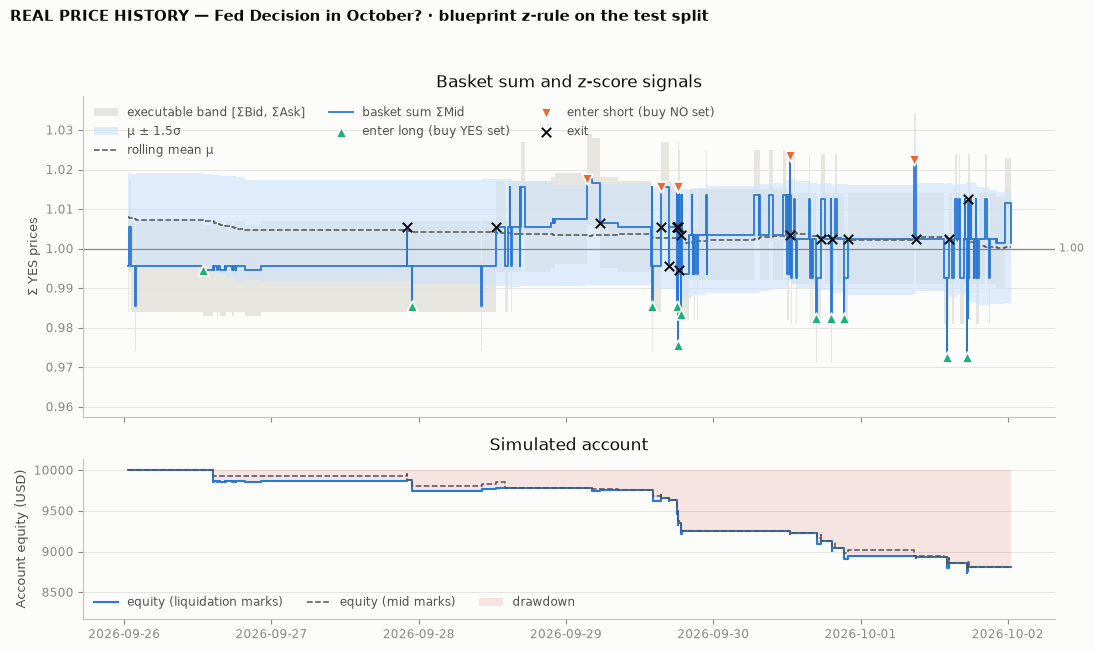

PosixPath('/home/user/bayes_project/results/figures/basket_signal_equity.png')

In [4]:
ser = A.series
t0 = pd.Timestamp(sel["test_start_ns"], tz="UTC") - pd.Timedelta(hours=12)
ser = ser[ser.index >= t0]
eq = A.equity[A.equity.index >= t0]
fig = P.plot_basket_signal_equity(ser, A.trades, eq, z_entry=sel["z_entry"], data_kind=DK,
                                  title=f"{ds.basket.title} · blueprint z-rule on the test split")
P.show(fig, "basket_signal_equity")

## 3. Institutional metrics (strategy A)

Sharpe uses period returns of the liquidation-marked equity curve sampled on a regular grid (hourly here, because the test split is shorter
than 30 days; prediction markets trade 24/7, so $P = 8760$), excess over a 4.2% risk-free rate. Drawdown duration runs from the peak to the
first recovery; an unrecovered drawdown is reported as *censored* (a lower bound).

,strategy A
trades,18
anecdotal (< 30 trades),True
net P&L ($),-1187.8183
total return,-0.1188
"Sharpe (1h, rf=4.2%)",-8.54
Sharpe (rf = 0),-8.3124
Sharpe 95% CI (block bootstrap),"[-13.28, -4.35]"
Sortino,-8.5974
max drawdown,-0.1265
max DD duration (h),131.5500


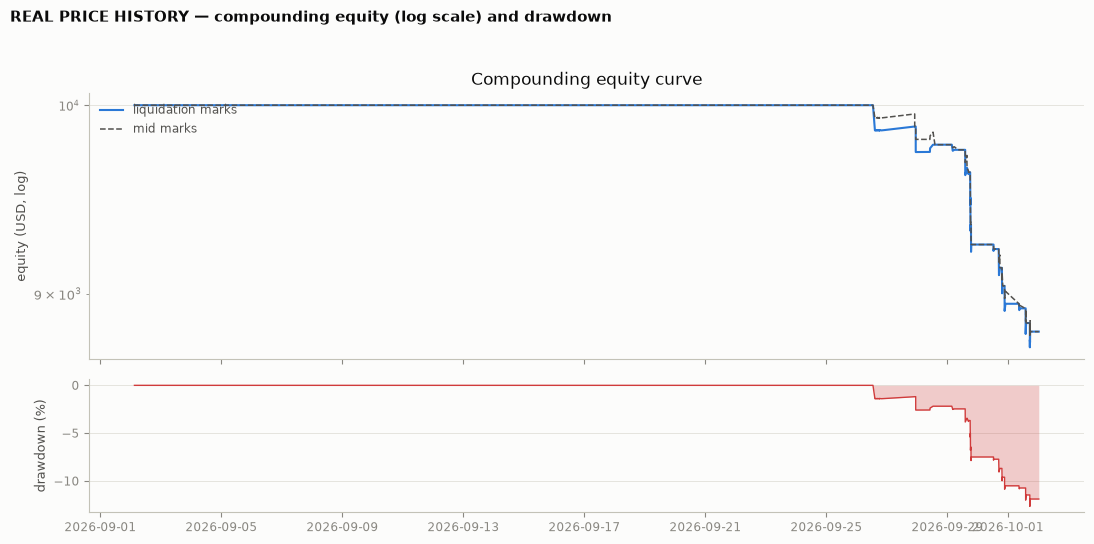

PosixPath('/home/user/bayes_project/results/figures/equity_log.png')

In [5]:
s = A.summary
t = A.trades
k, n = int((t["pnl_net"] > 0).sum()), len(t)
lo, hi = wilson_interval(k, n) if n else (float("nan"), float("nan"))
metrics = pd.Series({
    "trades": n, "anecdotal (< 30 trades)": n < 30,
    "net P&L ($)": A.attribution["net"], "total return": s["total_return"],
    f"Sharpe ({s['sharpe_freq']}, rf={s['rf_annual']:.1%})": s["sharpe_display"],
    "Sharpe (rf = 0)": s["sharpe_rf0"], "Sharpe 95% CI (block bootstrap)": f"[{s['sharpe_ci95_lo']:.2f}, {s['sharpe_ci95_hi']:.2f}]",
    "Sortino": s["sortino"], "max drawdown": s["max_dd"],
    "max DD duration (h)": (s["max_dd_duration_s"] or 0) / 3600, "max DD censored (not recovered)": s["max_dd_censored"],
    "peak-to-trough (h)": (s["peak_to_trough_s"] or 0) / 3600, "CAGR (short-sample flag)": f"{s['cagr']:.2%} ({'short sample' if s['short_sample'] else 'ok'})",
    "hit rate (Wilson 95%)": f"{k / n:.0%} [{lo:.0%}, {hi:.0%}]" if n else "n/a",
    "mean holding (h)": t["holding_s"].mean() / 3600 if n else float("nan"),
})
display(metrics.to_frame("strategy A"))
P.show(P.plot_equity_log(A.equity, data_kind=DK, title="compounding equity (log scale) and drawdown"), "equity_log")

## 4. Where the money went: exact P&L attribution

Every trade satisfies, to floating-point precision,
$\text{net} = \text{gross mid} + \text{latency drift} + \text{half spread} + \text{depth slippage} + \text{payoff adj.} - \text{fees} - \text{gas} - \text{legging}$.

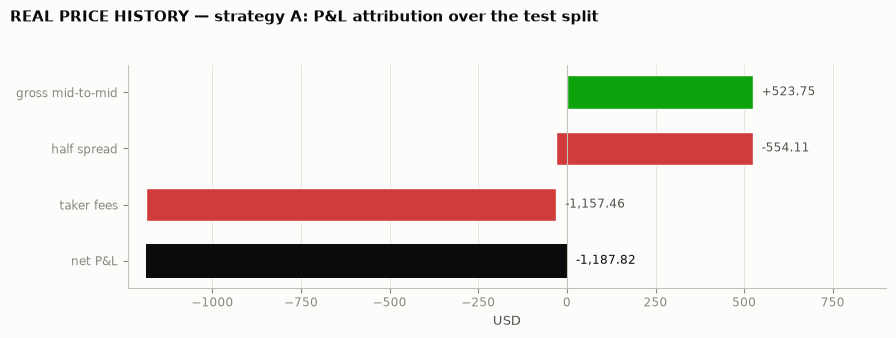

,count,sum,mean
outside_band_at_entry,,,
entered INSIDE the band (convergence bet),1,-118.1967,-118.1967
entered OUTSIDE the band (executable edge),17,-1069.6216,-62.9189


In [6]:
attr = {"gross mid-to-mid": A.attribution["gross_mid"], "latency drift": A.attribution["latency_drift"],
        "half spread": A.attribution["half_spread"], "depth slippage": A.attribution["depth_slippage"],
        "payoff adjustment": A.attribution["payoff_adjustment"], "taker fees": -A.attribution["fees"],
        "gas": -A.attribution["gas"], "legging": -A.attribution["legging_cost"], "net": A.attribution["net"]}
P.show(P.plot_attribution(attr, data_kind=DK, title="strategy A: P&L attribution over the test split"), "attribution")
if n:
    split = t.groupby("outside_band_at_entry")["pnl_net"].agg(["count", "sum", "mean"])
    split.index = split.index.map({True: "entered OUTSIDE the band (executable edge)", False: "entered INSIDE the band (convergence bet)"})
    display(split)

## 5. Sensitivity: fees, latency and execution assumptions (strategy A)

In [7]:
sens = []
for label, ex in [("as tested (fee 0.05, 0.5 s + jitter)", {}),
                  ("no taker fee (maker-like)", {"fee_mode": "usd"}),
                  ("zero latency", {"latency": dataclasses.replace(base.latency, base_ms=0.0, jitter_ms=0.0)}),
                  ("5 s latency", {"latency": dataclasses.replace(base.latency, base_ms=5000.0)}),
                  ("pessimistic: fill only on the next price update", {"require_newer_book": True}),
                  ("slippage guard 0 ticks", {"max_slip_ticks": 0})]:
    if label.startswith("no taker fee"):
        b0 = dataclasses.replace(ds.basket, legs=tuple(dataclasses.replace(l, fee=dataclasses.replace(l.fee, rate=0.0)) for l in ds.basket.legs))
        r = run(data=dataclasses.replace(ds, basket=b0))
    else:
        r = run(**ex)
    sens.append({"scenario": label, "trades": len(r.trades), "net P&L ($)": r.attribution["net"],
                 "gross mid ($)": r.attribution["gross_mid"], "fees ($)": -r.attribution["fees"],
                 "spread+slippage ($)": r.attribution["half_spread"] + r.attribution["depth_slippage"]})
sens = pd.DataFrame(sens).set_index("scenario")
display(sens)

,trades,net P&L ($),gross mid ($),fees ($),spread+slippage ($)
scenario,,,,,
"as tested (fee 0.05, 0.5 s + jitter)",18,-1187.8183,523.7512,-1157.4581,-554.1114
no taker fee (maker-like),18,-27.7069,559.2862,-0.0000,-586.9931
zero latency,18,-1187.8183,523.7512,-1157.4581,-554.1114
5 s latency,18,-1187.8183,523.7512,-1157.4581,-554.1114
pessimistic: fill only on the next price update,15,-1334.5504,494.6310,-1078.4934,-516.2620
slippage guard 0 ticks,18,-1187.8183,523.7512,-1157.4581,-554.1114


## 6. Cross-check on the recorded live order books

Real, executable books recorded from the WebSocket (hours, not weeks, so far: the recorder runs in ≤2 h chunks). Strategy C needs no
warm-up, so it is the meaningful test here: did the live books ever offer a riskless basket trade after walking depth and fees?

In [8]:
try:
    live = load_real_books(BASKET, cfg=cfg)
    display(Markdown(live.info.banner_markdown()))
    rc = RunConfig(strategy="arb", exec=dataclasses.replace(base, gate="arb_only", exit_policy="hold"))
    rl = run_backtest(live, rc)
    bs = R.book_sums(BASKET, cfg)
    band = R.band_stats(bs[0], ds.basket) if bs else {}
    live_row = {"hours": live.info.hours, "arb trades": len(rl.trades), "min S_ask": band.get("min S_ask"),
                "max S_bid": band.get("max S_bid"), "median n-leg spread": band.get("median spread_sum")}
    display(pd.DataFrame([live_row]))
except DataUnavailable as exc:
    live_row = None
    display(Markdown(f"_No recorded books: {exc}_"))

**DATA: REAL Polymarket order books** recorded live from the CLOB market WebSocket.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-10-01T22:30:10 | 2026-10-02T02:59:25 | 2.5 | 922 | 4 |

> Only 2.5 h of live books so far (recording continues in ≤2 h chunks); treat backtest statistics on this sample as anecdotal.

,hours,arb trades,min S_ask,max S_bid,median n-leg spread
0,2.5067,0,1.0130,0.9900,0.0230


In [9]:
def usd(x):
    return f"{'+' if x >= 0 else '−'}${abs(x):,.0f}"

lines = [
    f"* **The blueprint rule loses money after costs.** Strategy A made {len(A.trades)} round trips on the test split. Its gross mid-to-mid P&L was "
    f"**{usd(A.attribution['gross_mid'])}**: the z-signal *does* pick reversions. But half-spreads ({usd(A.attribution['half_spread'])}) and taker fees "
    f"({usd(-A.attribution['fees'])}) turned it into **{usd(A.attribution['net'])}** ({A.summary['total_return']:+.1%}).",
    f"* **Even fee-free it does not break even:** net {usd(sens.loc['no taker fee (maker-like)','net P&L ($)'])} with zero taker fees. Crossing a "
    f"{sel['spread_sum']:.3f} n-leg spread twice costs more than the typical reversion the signal captures.",
    f"* **Execution-aware gating is the fix, not a better z.** Strategy B (enter only if the exact exit-formula edge is positive) and strategy C "
    f"(riskless arbitrage only) both **stand aside** ({int(comp.loc['B · gated z (edge > 0)','trades'])} and {int(comp.loc['C · arbitrage only','trades'])} trades): "
    "on this basket in this window the sum never left the no-arbitrage band by more than costs.",
    f"* **Convert matters for the short side:** with NegRisk convert enabled, A's loss shrinks to {usd(comp.loc['A · blueprint z, convert on','net P&L ($)'])} "
    "(full NO sets settle at n-1 instead of being sold back across the spread).",
]
if live_row:
    lines.append(f"* **Live books agree:** over {live_row['hours']:.1f} recorded hours S_ask stayed ≥ {live_row['min S_ask']:.3f} and S_bid ≤ "
                 f"{live_row['max S_bid']:.3f}; strategy C found {live_row['arb trades']} trades.")
lines.append("* **What would make it work:** quoting passively (earning instead of paying the spread, and maker rebates instead of taker fees), "
             "or baskets whose sum dislocates by more than the hurdle (ECR > 1 in notebook 01): exactly the pro-tip-2 filter.")
display(Markdown("### Conclusions (generated from the numbers above)\n" + "\n".join(lines)))

### Conclusions (generated from the numbers above)
* **The blueprint rule loses money after costs.** Strategy A made 18 round trips on the test split. Its gross mid-to-mid P&L was **+$524**: the z-signal *does* pick reversions. But half-spreads (−$554) and taker fees (−$1,157) turned it into **−$1,188** (-11.9%).
* **Even fee-free it does not break even:** net −$28 with zero taker fees. Crossing a 0.023 n-leg spread twice costs more than the typical reversion the signal captures.
* **Execution-aware gating is the fix, not a better z.** Strategy B (enter only if the exact exit-formula edge is positive) and strategy C (riskless arbitrage only) both **stand aside** (0 and 0 trades): on this basket in this window the sum never left the no-arbitrage band by more than costs.
* **Convert matters for the short side:** with NegRisk convert enabled, A's loss shrinks to −$1,071 (full NO sets settle at n-1 instead of being sold back across the spread).
* **Live books agree:** over 2.5 recorded hours S_ask stayed ≥ 1.013 and S_bid ≤ 0.990; strategy C found 0 trades.
* **What would make it work:** quoting passively (earning instead of paying the spread, and maker rebates instead of taker fees), or baskets whose sum dislocates by more than the hurdle (ECR > 1 in notebook 01): exactly the pro-tip-2 filter.

In [10]:
def clean(v):
    if isinstance(v, (np.floating, float)):
        return None if not math.isfinite(float(v)) else float(v)
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (pd.Timestamp, pd.Timedelta)):
        return str(v)
    return v

out = {"basket": BASKET, "data_kind": DK, "test": sel["test"], "params": {k: sel[k] for k in ("window", "z_entry", "z_exit")},
       "strategies": {k: {kk: clean(vv) for kk, vv in row(k, v).items()} for k, v in runs.items()},
       "headline": {k: clean(v) for k, v in A.summary.items() if not isinstance(v, (dict, list))},
       "attribution_A": {k: clean(v) for k, v in A.attribution.items()},
       "sensitivity": {i: {k: clean(v) for k, v in r.items()} for i, r in sens.iterrows()},
       "live_books": {k: clean(v) for k, v in live_row.items()} if live_row else None}
(RESULTS_ROOT / "metrics.json").write_text(json.dumps(out, indent=1, default=str))
A.trades.drop(columns=[c for c in A.trades.columns if c.startswith("attr_")], errors="ignore").to_csv(RESULTS_ROOT / "trades.csv", index=False)
R.save_dataset_info("03", [ds.info] + ([live.info] if live_row else []))
print("wrote results/metrics.json, results/trades.csv, results/dataset_info_03.json")

wrote results/metrics.json, results/trades.csv, results/dataset_info_03.json


### Limitations
* **Modelled books.** On the price-history test split the bid/ask/depth used for execution are modelled around the real 1-minute mids, with
  per-leg spreads equal to the median spread of the recorded live books. Real books can be thinner or wider at the moments that matter.
* **Latency is unresolvable at 1-minute sampling.** Between two price-history samples the modelled book is constant, so 0 s, 0.5 s and 5 s latency
  give identical fills; the "fill only on the next price update" row is the pessimistic bound. Sub-second effects need the recorded WebSocket books.
* **One basket, one week of test data, under 30 trades:** the statistics are anecdotal; the bootstrap intervals say how wide.
* **Simulation only.** No orders are placed. Legging risk is real (Polymarket has no atomic multi-leg orders), resolution and dispute
  risk are not modelled, and NegRisk *convert* availability for CLOB-V2 pUSD positions is unverified (hence reported both ways).